# CNN Classifier

In [22]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import kagglehub
import matplotlib.pyplot as plt
from tqdm import tqdm

### Download Dataset
* link: https://www.kaggle.com/datasets/ankit1743/skyview-an-aerial-landscape-dataset

In [15]:
path = kagglehub.dataset_download("ankit1743/skyview-an-aerial-landscape-dataset")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Create Dataset loader

In [16]:
dataset = datasets.ImageFolder(
    root=f'{path}/Aerial_Landscapes',
    transform=transforms.ToTensor()
)

class_indices = {}

for i in range(len(dataset)):
    _,label = dataset[i]
    if label not in class_indices:
        class_indices[label] = []
    class_indices[label].append(i)

train_indices = []
val_indices = []
test_indices = []

for label in class_indices:
    indices = class_indices[label]
    
    train_split = int(len(indices) * 0.6)
    val_split = int(len(indices) * 0.7)
    test_split = int(len(indices) * 0.8)
    
    train_indices.extend(indices[:train_split])
    val_indices.extend(indices[train_split:val_split])
    test_indices.extend(indices[val_split:test_split])

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)

### Dataloader

In [26]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Model

In [18]:
class ClassifierModel(nn.Module):
    def __init__(self, num_classes=15):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        
        self.flatten = nn.Flatten()
        
        # Fully connected layers
        # 256x256 -> after 5 pooling layers: 8x8
        # 256 feature maps of size 8x8 = 256 * 8 * 8
        self.fc1 = nn.Linear(256 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 256x256 -> 128x128        
        x = self.pool(self.relu(self.conv2(x)))  # 128x128 -> 64x64
        x = self.pool(self.relu(self.conv3(x)))  # 64x64 -> 32x32
        x = self.pool(self.relu(self.conv4(x)))  # 32x32 -> 16x16
        x = self.pool(self.relu(self.conv5(x)))  # 16x16 -> 8x8

        # Fully connected layers
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

In [43]:
model = ClassifierModel().to(device)

lr = 0.0005
optimizer = torch.optim.Adam(params=model.parameters(),lr=lr)
loss_fn = nn.functional.cross_entropy

### Train

Epoch 1 running!


Validation: 100%|██████████| 19/19 [00:01<00:00, 11.24batch/s]


Epoch 2 running!


Validation: 100%|██████████| 19/19 [00:01<00:00, 11.14batch/s]


Epoch 3 running!


...

Validation: 100%|██████████| 19/19 [00:01<00:00, 11.07batch/s]


Epoch 14 running!


Validation: 100%|██████████| 19/19 [00:01<00:00, 11.09batch/s]


Epoch 15 running!


Validation: 100%|██████████| 19/19 [00:01<00:00, 10.95batch/s]


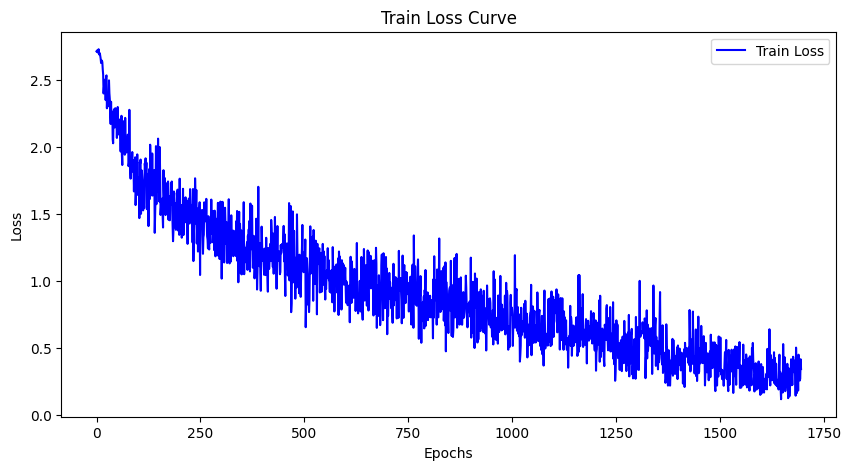

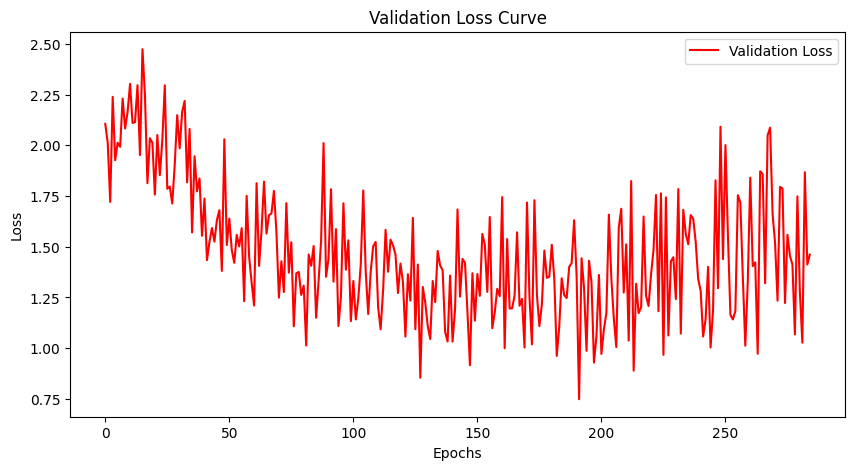

In [44]:
epochs = 15

train_loss = []
val_loss = []

for i in range(epochs):
    print(f"Epoch {i+1} running!")
    
    model.train()
    for X,t in tqdm(train_loader, unit="batch",desc="Training"):
        X,t = X.to(device),t.to(device)
        
        y = model(X)
        loss = loss_fn(y,t)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        for X,t in tqdm(val_loader, unit="batch",desc="Validation"):
            X,t = X.to(device),t.to(device)
            y = model(X)
            loss = loss_fn(y,t)
            val_loss.append(loss.item())

# Plot Train Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Train Loss", color='blue')
plt.title("Train Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(val_loss, label="Validation Loss", color='red')
plt.title("Validation Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Test

In [45]:
model.eval()
cnt = 3

correct = 0
total = 0
with torch.no_grad():
    for X,t in tqdm(test_loader, unit="batch",desc="Testing"):
        X,t = X.to(device),t.to(device)
        y = model(X)
        
        if torch.argmax(y, dim=1).item() == t.item():
            correct += 1
        
        total += 1

accuracy = (correct/total)*100
print(f"Accuracy: {accuracy}")
        

Testing: 100%|██████████| 1200/1200 [00:02<00:00, 451.59batch/s]

Accuracy: 59.166666666666664
